<a href="https://colab.research.google.com/github/lspnzz/granted-search-engine/blob/main/evals/notebooks/recall_evals_comparison_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recall Eval Runs Comparison Template**
Run this notebook to compare and evaluate different runs.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files
import datetime
import io
import os

print("Please upload the recall eval run files you want to compare.")
uploaded = files.upload()

Please upload the recall eval run files you want to compare.


Saving 2026-01-12_model-text-embedding-3-small_dimensions-1536-cosine_chunk-size-2000_chunk-overlap-200_top-10_recall.csv to 2026-01-12_model-text-embedding-3-small_dimensions-1536-cosine_chunk-size-2000_chunk-overlap-200_top-10_recall.csv
Saving 2026-01-13_model-text-embedding-3-small_dimensions-1536_metric-cosine_chunk-size-2000_chunk-overlap-200_top-23_recall.csv to 2026-01-13_model-text-embedding-3-small_dimensions-1536_metric-cosine_chunk-size-2000_chunk-overlap-200_top-23_recall.csv


Parse filenames and extract run metadata:

In [8]:
import re

def parse_filename(filename):
    """
    Extracts parameters from the filename format:
    date_model-X_dimensions-X_metric-X_chunk-size-X_chunk-overlap-X_top-X_recall.csv
    """
    clean_name = filename.replace('_recall.csv', '').replace('.csv', '')

    patterns = {
        'model': r'model-([^_]+)',
        'dims': r'dimensions-(\d+)',
        'metric': r'metric-([^/_-]+)',
        'chunk_size': r'chunk-size-(\d+)',
        'overlap': r'chunk-overlap-(\d+)',
        'top_k': r'top-(\d+)'
    }

    metadata = {'filename': filename}
    for key, pattern in patterns.items():
        match = re.search(pattern, clean_name)
        metadata[key] = match.group(1) if match else "N/A"

    # Create a short label for charts (e.g., "small (1536) - top 23")
    metadata['label'] = f"{metadata['model']} ({metadata['dims']}) K={metadata['top_k']}"
    return metadata

all_metadata = []
dfs = {}

for filename, content in uploaded.items():
    meta = parse_filename(filename)
    all_metadata.append(meta)

    df = pd.read_csv(io.BytesIO(content))
    dfs[meta['label']] = df.set_index('pitch_id')['recall']

comparison_df = pd.DataFrame(dfs)
metadata_df = pd.DataFrame(all_metadata).set_index('label')

Overview:

In [18]:
stats = comparison_df.describe().T
summary_combined = metadata_df.join(stats[['mean', 'std']])
summary_combined[['model', 'dims', 'chunk_size', 'overlap', 'top_k', 'mean', 'std']].sort_values('mean', ascending=False).style.hide(axis='index')

model,dims,chunk_size,overlap,top_k,mean,std
text-embedding-3-small,1536,2000,200,23,0.474183,0.357729
text-embedding-3-small,1536,2000,200,10,0.340196,0.311523


Visualisations:

In [23]:
def plot_leaderboard(df, pdf_pages=None):
    run_performance = df.mean().sort_values(ascending=False)
    plt.figure(figsize=(12, 4))

    ax = sns.barplot(
            x=run_performance.index,
            y=run_performance.values,
            hue=run_performance.index,
            palette='viridis',
            legend=False)

    plt.title('Leaderboard: Average Recall by Run', fontsize=12)
    plt.ylabel('Mean Recall Score', fontsize=12)
    plt.ylim(0, 1.1)  # Set limit slightly above 1 for the text labels
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xlabel('', fontsize=12)
    plt.xticks(rotation=15, ha='right')

    # Add Score Labels on Top of Bars
    for i, v in enumerate(run_performance.values):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()

    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')

    plt.show()

def plot_distribution(df, pdf_pages=None):
    sorted_cols = df.mean().sort_values(ascending=False).index
    df_sorted = df[sorted_cols]

    plt.figure(figsize=(12, 7))
    # showmeans=True adds a small green triangle for the average,
    # which is often different from the median (the line inside the box).
    sns.boxplot(data=df_sorted, showmeans=True,
                meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"green", "markersize": "10"})

    plt.title('Recall Distribution by Run (Sorted by Mean Performance)', fontsize=12)
    plt.ylabel('Recall Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=15, ha='right')

    plt.tight_layout()

    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')

    plt.show()

def plot_trends(df, pdf_pages=None):
    line_df = df.copy()
    line_df['mean_score'] = line_df.mean(axis=1)
    line_df = line_df.sort_values('mean_score', ascending=False).drop(columns='mean_score')

    plt.figure(figsize=(20, 8))
    x_indices = np.arange(len(line_df))

    for col in line_df.columns:
        plt.plot(x_indices, line_df[col], marker='.', label=col, alpha=0.7, linewidth=1.5)

    # Formatting
    plt.xticks(x_indices, line_df.index, rotation=90, fontsize=8)
    plt.xlabel('Pitch ID (Sorted by Difficulty)', fontsize=12)
    plt.ylabel('Recall Score', fontsize=12)
    plt.title('Performance Trends across Runs', fontsize=16)

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') # Place legend outside if many runs
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')

    plt.show()

def plot_heatmap(df, pdf_pages=None):
    heatmap_df = df.copy()
    heatmap_df['mean_score'] = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.sort_values('mean_score', ascending=False).drop(columns='mean_score')

    dynamic_height = max(8, len(heatmap_df) * 0.10)
    plt.figure(figsize=(12, dynamic_height))

    sns.heatmap(heatmap_df,
                cmap='YlGnBu',
                linewidths=0.5,
                cbar_kws={'label': 'Recall Score'})

    plt.title(f'Performance Heatmap: {len(df.columns)} Runs\n(Sorted by Average Recall)', fontsize=12)
    plt.tight_layout()

    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')

    plt.show()

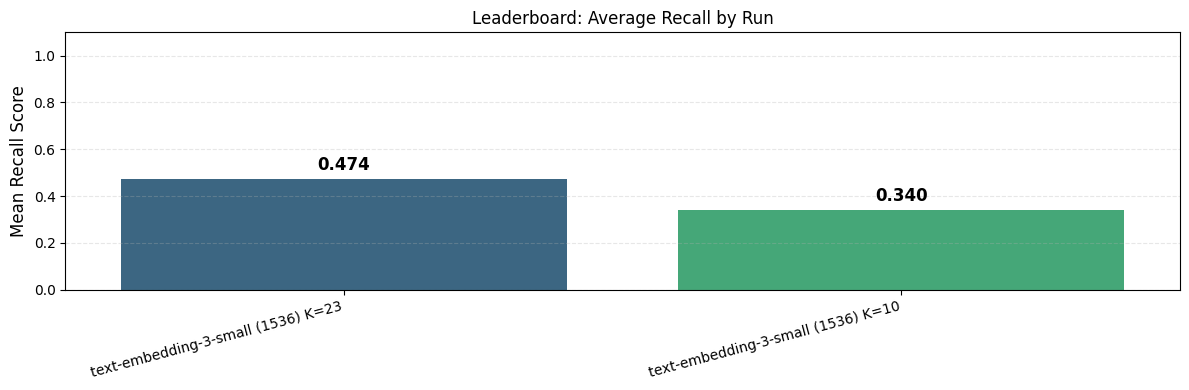

In [24]:
plot_leaderboard(comparison_df)

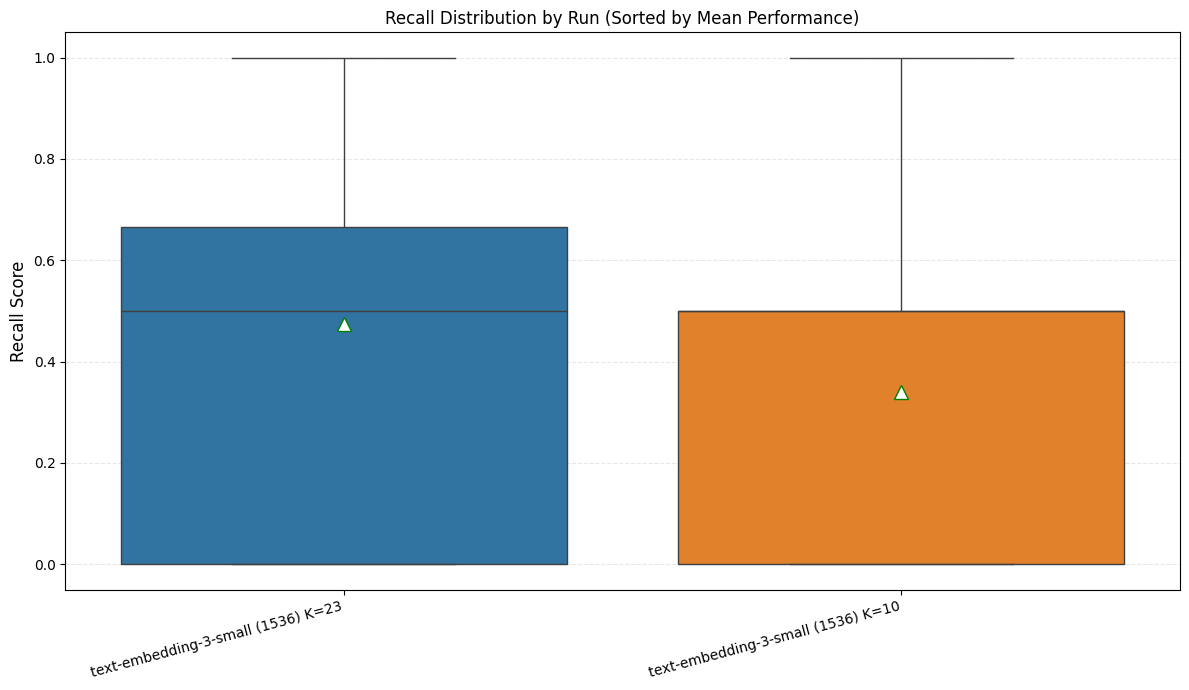

In [25]:
plot_distribution(comparison_df)

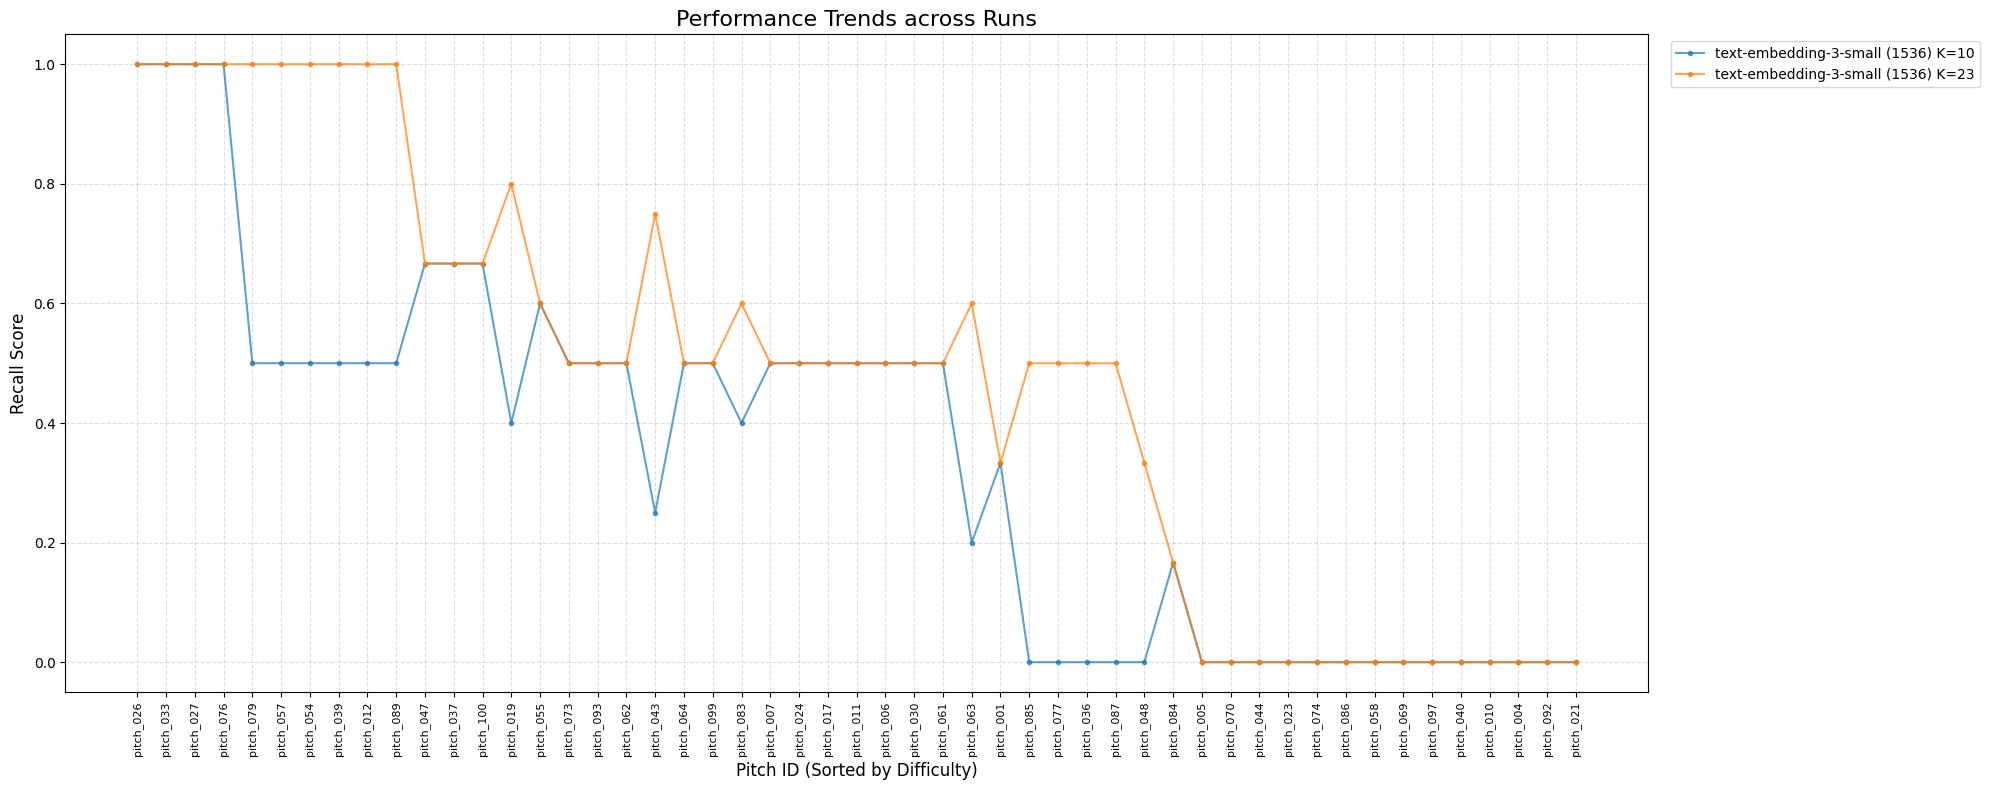

In [16]:
plot_trends(comparison_df)

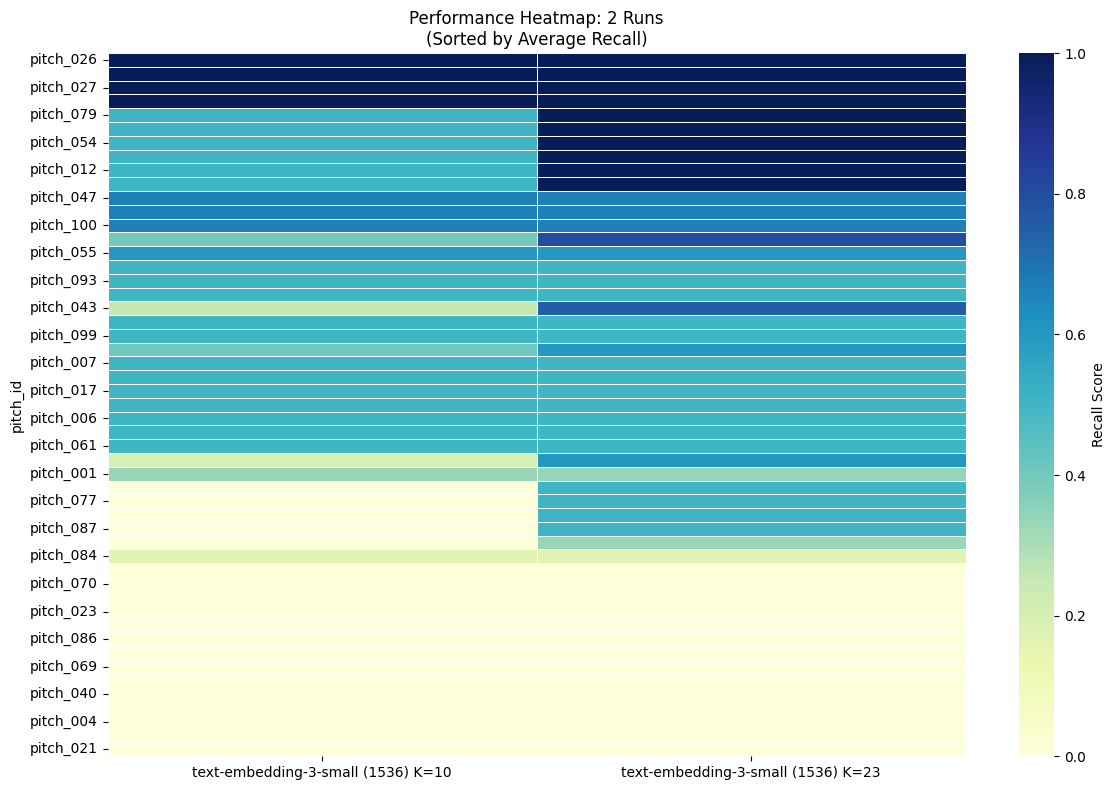

In [17]:
plot_heatmap(comparison_df)

Create a PDF snapshot:

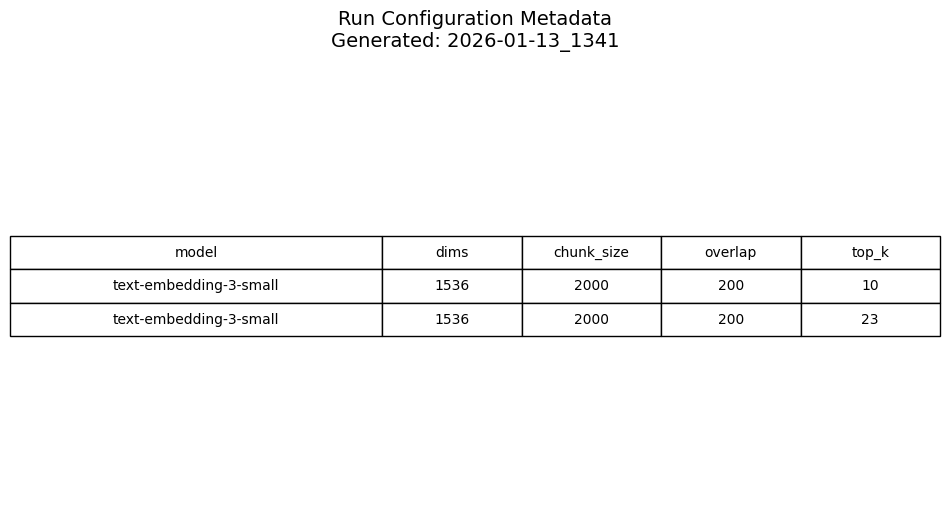

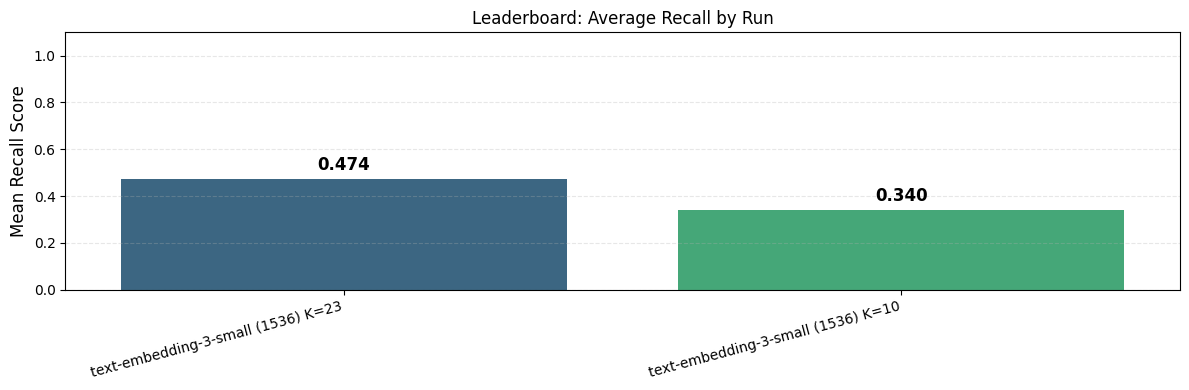

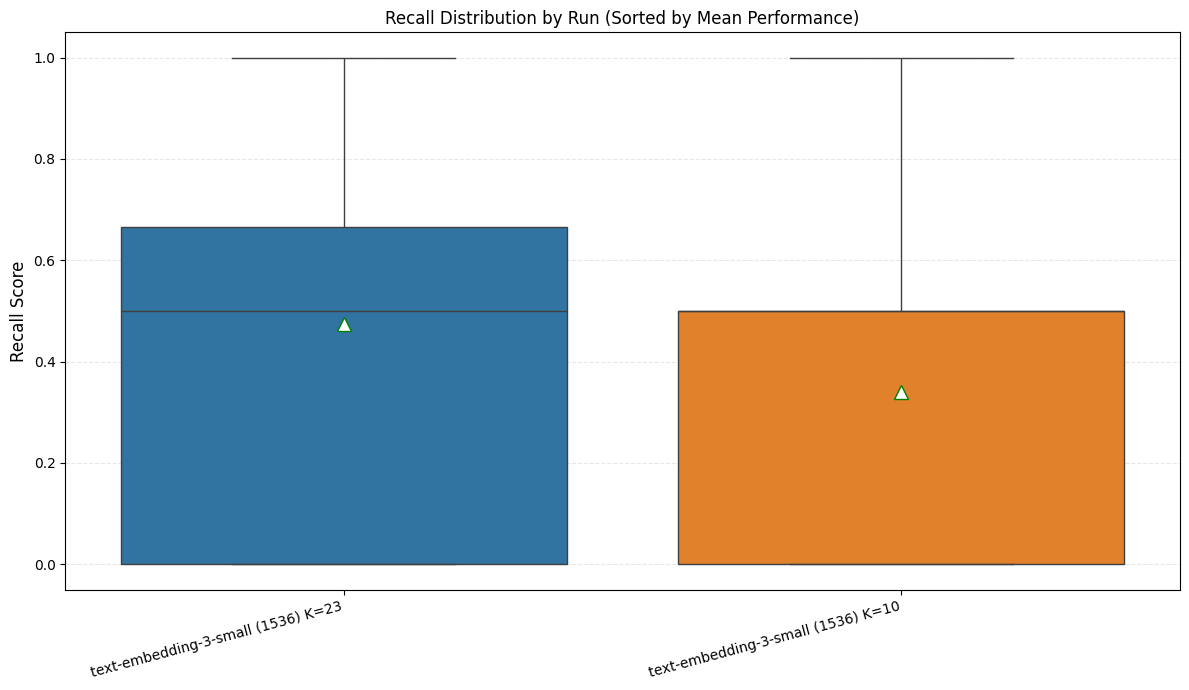

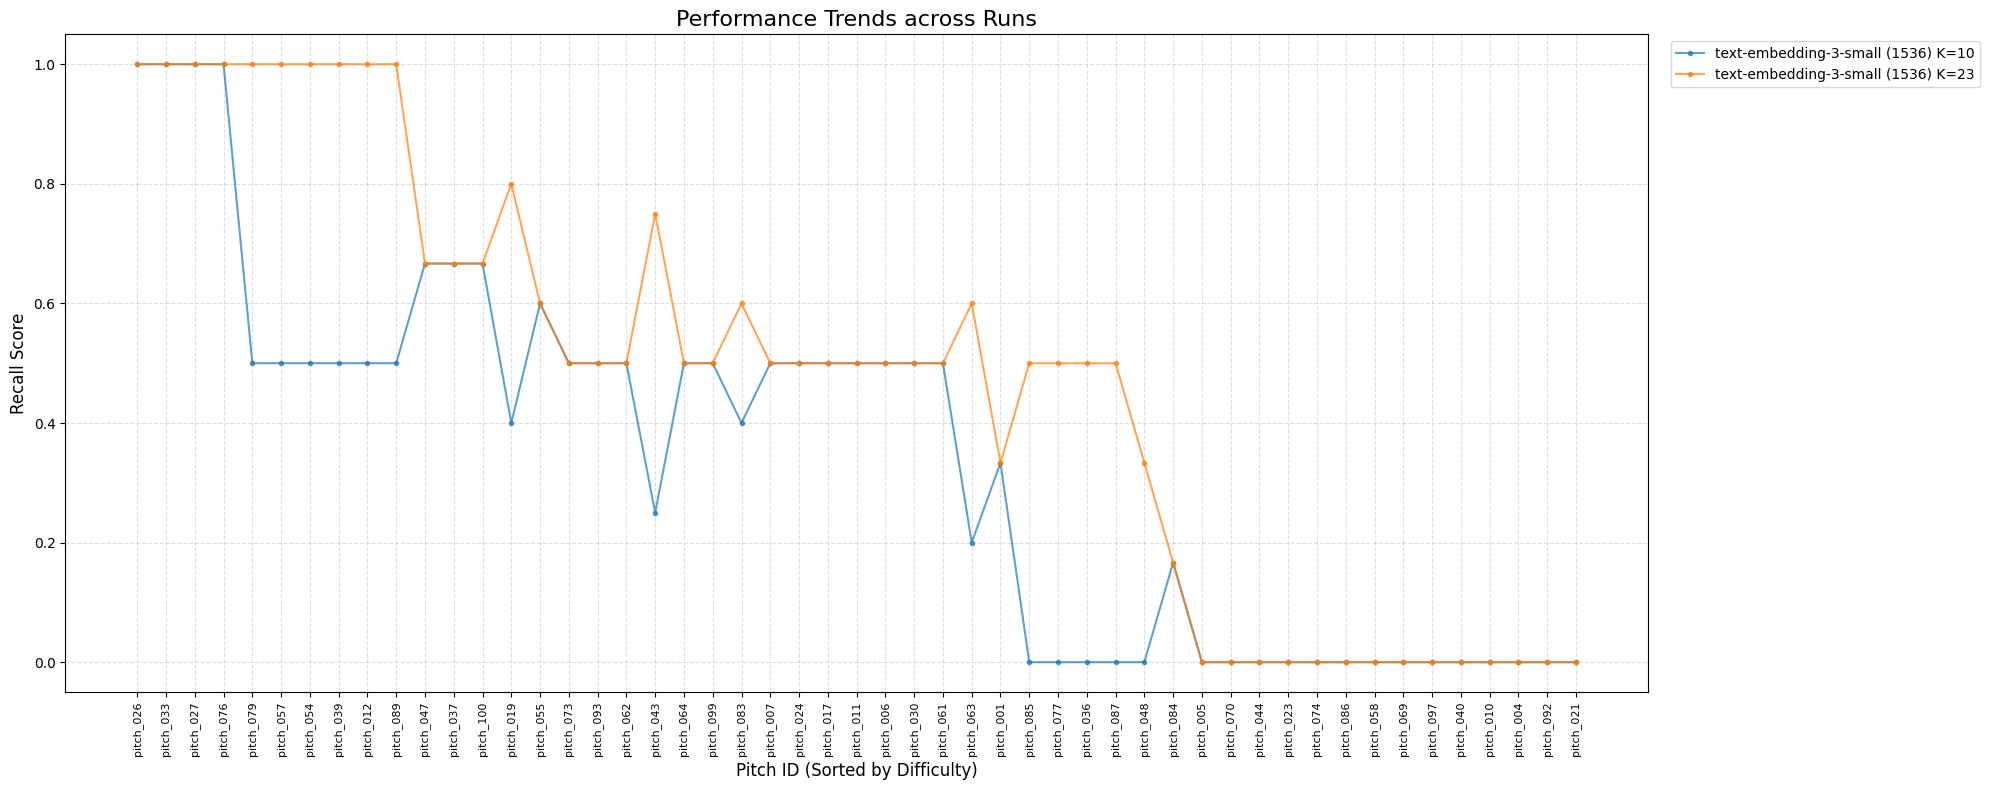

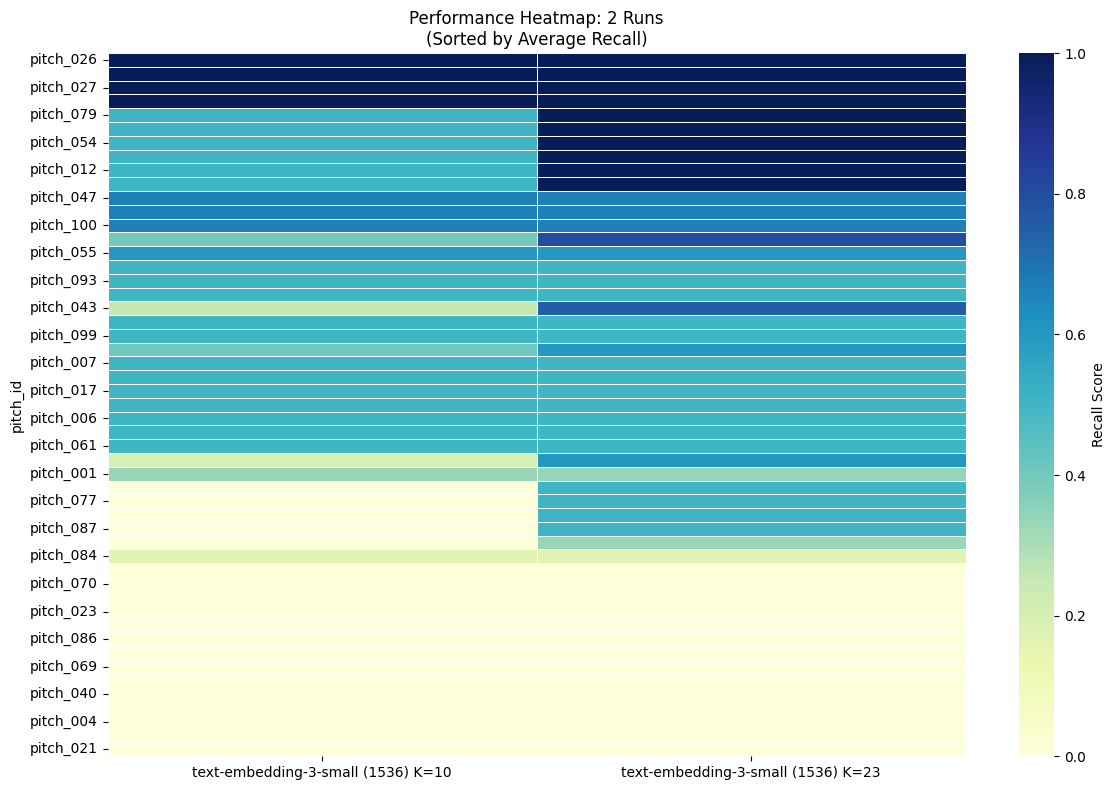

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

def plot_metadata_page(metadata_df, pdf_pages=None):
    """Creates a table of run configurations for the first page of the PDF."""
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')

    display_cols = ['model', 'dims', 'chunk_size', 'overlap', 'top_k']
    table_data = metadata_df[display_cols]
    col_labels = table_data.columns.tolist()
    cell_text = table_data.values.tolist()
    col_widths = [0.4, 0.15, 0.15, 0.15, 0.15]

    table = ax.table(cellText=cell_text,
                     colLabels=col_labels,
                     colWidths=col_widths,
                     loc='center',
                     cellLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)  # Stretch rows

    plt.title(f"Run Configuration Metadata\nGenerated: {timestamp}", fontsize=16)

    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight')

    plt.show()
    plt.close()


timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H%M")
pdf_filename = f"recall_eval_report_{timestamp}.pdf"
csv_filename = f"recall_eval_summary_{timestamp}.csv"

with PdfPages(pdf_filename) as pdf:
    plot_metadata_page(summary_combined, pdf)
    plot_leaderboard(comparison_df, pdf)
    plot_distribution(comparison_df, pdf)
    plot_trends(comparison_df, pdf)
    plot_heatmap(comparison_df, pdf)

    d = pdf.infodict()
    d['Title'] = 'Recall Evaluation Comparison'
    d['CreationDate'] = datetime.datetime.now()

files.download(pdf_filename)

# Save the summary table (stats + metadata) to CSV
summary_combined.to_csv(csv_filename)
files.download(csv_filename)